vielä kerran: henkilöittäin, 2015-2025, varianssianalyysi per hlö
- ympätään datat 2015-2025
- erotellaan henkilöittäin
- pidetään puheiden aikaleimat, paino pois vuosilta
- lemmatisoitu ja lemmatisoimaton
- varianssi ajan myötä, tarkastelu per henkilö
- koitetaan saada ennen ennen kesälomia

In [1]:
# import packages, declare constants, get the parent directory
import pandas as pd
import numpy as np
import re
import os
import time
#import decimal
from scipy import stats
#from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import colormaps
#from .utils import helpers
#import simplemma
import pyvoikko

CHATGPT_RELEASE_YEAR = int(2022)
FINNISH_ALPHABET = 'abcdefghijklmnopqrstuvwxyzåäö'

def get_parent_directory() -> str:
    """Get the parent directory for handling csv files.

    Returns:
        string: the path to the directory where directories for csv files are located
    """
    #create relative path for parent
    relative_parent = os.path.join(os.getcwd(), '..')

    #use abspath for absolute parent path
    return str(os.path.abspath(relative_parent)).replace('\\', '/')

directory = get_parent_directory()

In [2]:
# Read the csvs of speeches, years 2015-2025. Combine into a singel dataframe. The dataframe will include a column with lemmatised version of the speech 
# and an original unlemmatised version.
# Running this cell does nothing but creates the dataset for analysis.
#for csv in [i for i in os.listdir(f'{directory}/csv_lemmatized/') if re.search('\d+',i)[0] >= 2015]:
df_all_years = pd.DataFrame()

for csv in [i for i in os.listdir(f'{directory}/csv_lemmatized/') if re.search(r'\d+', i)]:
    if int(re.search(r'\d+', csv)[0]) < 2015:
        pass
    else:
        df_year = pd.read_csv(f'{directory}/csv_lemmatized/{csv}', sep=';', header=0, encoding='utf-8')
        df_all_years = pd.concat([df_all_years, df_year])


In [3]:
# Keep only rows where the speaker identifier (speaker_id) is present. Some are missing for some reason.
df_all_years = df_all_years.loc[pd.notna(df_all_years['speaker_id'])]
df_all_years = df_all_years.loc[df_all_years['speaker_id'].str.strip().str.len()>0]

In [4]:
# Keep only rows with the speech_type category in: 'Esittelypuheenvuoro', 'Ryhmäpuheenvuoro', 'Varsinainen puheenvuoro', 'Puheenvuoro'
#    -> Drop rows with other categories.
#    This is to limit the rows to speeches where preparation (ergo option for using generative AI) is necessary.
# Clean and prep data before filtering:
# - Clean speech_type, fix known spelling errors

list_wanted_speech_types = ['Esittelypuheenvuoro', 'Ryhmäpuheenvuoro', 'Varsinainen puheenvuoro', 'Puheenvuoro']

def clean_speech_type(speech_type: str) -> str:
    if 'vastauspuheenvuoro' in speech_type:
        return 'Vastauspuheenvuoro'
    elif 'esittelypuheenvuoro' in speech_type:
        return 'Esittelypuheenvuoro'
    else:
        return speech_type.strip()

# Clean speech_type
df_all_years.loc[:, 'speech_type'] = df_all_years['speech_type'].apply(clean_speech_type)
# Filter rows
df_all_years = df_all_years[df_all_years['speech_type'].isin(list_wanted_speech_types)]

In [5]:
# What happens in this cell:
# Data preparation:
# - Lemmatise the rows which have not yet been lemmatised (due to data errors or some coding oversight earlier in the process)
# - The actual process of lemmatisation is done with separate functions
# - Because lemmatisation takes long, the process is split into parts
# -- filter rows which have to be lemmatised -> store in a separate df
# -- lemmatise these rows in their respective df
# -- concat these rows back into the main df

def clean_string(string: str) -> str:
    try:
        # remove blanks in start and end
        string = string.strip()
        string = string.lower()
        # the string must contain characters
        if any(c in string for c in FINNISH_ALPHABET)==False:
            string = ''
        # remove tabulations, line breaks etc., also special characters
        remove_these = r'[\+\*!"”’?.:,…()§\'[\] \t\n\r\f\v]'
        string = re.sub(remove_these, '', string)
        # remove weird parentheses and backwards linebreaks from starts of strings
        string = re.sub(r'^\)\\[a-z]', '', string)
        # remove weird '\[alphabet]' strings at start of strings
        string = re.sub(r'^\\[a-z]', '', string)
        # remove numbers
        string = re.sub(r'[0-9]', '', string)
        # remove dashes '-' at the start and end of string
        string = re.sub(r'^-|-$', '', string)
        # remove individual forward and backward slashes '/', '\'
        string = re.sub(r'[\/\\]', '', string)
        # remove double dashes '--'
        string = string.replace('--', '-')
        # remove the equal sign '='
        string = string.replace('=', '')
        # at the end of the cleaning, remove all characters from the string which are not in the alphabet except for dash (compound words)
        remove_these = ''.join([str(c) for c in string if c != '-' and c not in [i for i in FINNISH_ALPHABET]])
        string = re.sub(remove_these, '', string)
        # remove blanks in start and end again
        string = string.strip()
        # remove empty if string length < 2
        string = '' if len(string) < 2 else string
        return string
    except:
        print(f'Unexpected error at helpers.clean_string(), string: {string}')
        raise

def pyvoikko_wrapper(str_in: str) -> str:
    """A small wrapper for pyvoikko Finnish text analysis tool.
    Used to help lemmatizing strings. Uses the clean_string helper function.
    NOTE: omits the etunimi (given name) word class returned in PyVoikko.

    Args:
        str_in (str): input string to lemmatize

    Returns:
        str: string of lemmatized words; input string in lemmatized form
    """
    # format output string
    str_out = str()
    # turn input string into a list
    str_in = str_in.split()
    for i in str_in:
        i = pyvoikko.analyse(clean_string(i))
        if (i is not None) and (len(i)>0) and (i[0].CLASS != 'etunimi'):
            str_out = str_out+' '+i[0].BASEFORM
    if len(str_out) == 0:
        return None
    else:
        return str_out.strip()

lemmatise_df = df_all_years.loc[(pd.isna(df_all_years['content_lemmatized']))&(df_all_years['lang']=='fi')&(type(df_all_years['content'])==str)]

if len(lemmatise_df)>0:
    # lemmatise material, if "lemmatisable" rows exist
    lemmatise_df.loc[:, 'content_lemmatized'] = lemmatise_df.apply(lambda x: pyvoikko_wrapper(x['content']), axis=1)
    # update df_all_years dataframe's content_lemmatized with content created above
    df_all_years.update(lemmatise_df)

In [6]:
# Keep only rows where content_lemmatized is not None and the length of content_lemmatized is over 0 
# -> actual information is stored in there
df_all_years = df_all_years.loc[(pd.notna(df_all_years['content_lemmatized']))&(len(df_all_years['content_lemmatized'])>0)]

In [8]:
# Clean lemmatised content (content_lemmatized column). Drop special characters etc., so that the lemmatised content is similar throughout the dataframe
# and special characters etc. do not interfere.
# A small wrapper for the clean_string function for this purpose.

def clean_string_wrapper(str_in: str) -> str:
    # format output string
    str_out = str()
    # turn input string into a list of words, cut at SPACE
    str_in = str_in.split()
    for i in str_in:
        i = clean_string(i)
        if (i is not None) and (len(i)>0):
            str_out = str_out+' '+i
    if len(str_out)==0:
        return None
    else:
        return str_out.strip()

df_all_years.loc[:, 'content_lemmatized'] = df_all_years.apply(lambda x: clean_string_wrapper(x['content_lemmatized']), axis=1)

# If lemmatisation and string cleaning has nulled any speeches, drop such rows
df_all_years = df_all_years.loc[pd.notna(df_all_years['content_lemmatized'])]
df_all_years.reset_index(inplace=True)

In [9]:
# Data preparation is now finished.
# What the dataframe looks like now:
df_all_years[:1].T

,0
index,24
speech_id,2015_2_6
session,2/2015
date,2015-05-05
start_time,14.01
end_time,14.15
given,Sirkka-Liisa
family,Anttila
role,Kansanedustaja
party,KESK


The analysis part starts here.
Next the goal is to calculate word frequencies per speaker to see if there are significant changes speaker-wise.
The data will not be grouped by year, so the frequencies will not be based on yearly aggregates of observations. Frequencies will be calculated for each speech. Each speech has a unique speech identifier (speech_id).
To make it possible to do this for each speaker, several different datasets will be created:
- A list that holds all unique speaker identifiers.
- A dataframe that holds speaker_id, speech_id and session identifier (session)
- A dataframe that holds all words and their frequencies per speech

In [10]:
# Next:
# - Store each speaker_id (speaker identifier) in a list: speakers
speakers = df_all_years['speaker_id'].unique()

In [11]:
# Next: Get each speakers' speech and session identifiers. Store them in a dataframe: df_speeches_sessions
df_speeches_sessions = pd.DataFrame(columns=['speaker_id','session','speech_id','content','content_lemmatized']).astype({'speaker_id':str, 'session':str, 'speech_id':str, 'content':str, 'content_lemmatized':str})

# Populate the dataframe
for speaker in speakers:
    df_speeches_sessions = pd.concat([df_speeches_sessions, df_all_years[['speaker_id','session','speech_id','content','content_lemmatized']].loc[df_all_years['speaker_id']==speaker]], axis=0, ignore_index=True)

In [ ]:
# Next: Get all words per speaker per speech. Store them in a dataframe: df_speech_session_words.
# Store the dataframe (containing information 'speaker_id','session','speech_id','word','word_n') as a csv:
#    a csv will be created for each speaker; each speaker's data will be in their respective csv.
def count_word_freqs_in_string(string: str):
    """Counts the words in the input string.
    Returns a dictionary where the word is the key and the frequency is the value.
    """
    if ((string is None) or (string == 'nan')):
        return None
    else:
        words_list = re.split(' ', string)
        wordfreq_dict = {}
        for word in words_list:
            if word not in wordfreq_dict.keys():
                wordfreq_dict[word] = 1
            else:
                wordfreq_dict[word] += 1

        return wordfreq_dict

# Populate the dataframe with help from the function declared above
for speaker in speakers:
    # Format a df to store the results -> this will be saved as a csv for later use
    df_speech_session_words = pd.DataFrame(columns=['speaker_id','session','speech_id','word','word_n']).astype({'speaker_id':str,'session':str,'speech_id':str,'word':str,'word_n':int})
    # A name for csv in a helper variable.
    csv_name = f'speaker_{speaker}_words_speeches_sessions.csv'
    csv_save_directory = f'{directory}/csv_analysis/person_variance/'
    csv_save_path = f'{directory}/csv_analysis/person_variance/{csv_name}'
    # If the csv already exists (speaker's data has already been created) -> skip and move to the next speaker
    if csv_name in os.listdir(csv_save_directory):
        pass
    else:
        for speech in df_speeches_sessions['speech_id'].loc[df_speeches_sessions['speaker_id']==speaker]:
            session = df_speeches_sessions['session'].loc[(df_speeches_sessions['speaker_id']==speaker)&(df_speeches_sessions['speech_id']==speech)].item()
            cont_lem = df_speeches_sessions['content_lemmatized'].loc[(df_speeches_sessions['speaker_id']==speaker)&(df_speeches_sessions['speech_id']==speech)].item()
            # We have now targeted down to the speech content. Let's count how many times each word appears in the speech.
            word_counts = count_word_freqs_in_string(cont_lem)
            # Let's store the results!
            for word, count in word_counts.items():
                df_speech_session_words = pd.concat([df_speech_session_words, pd.DataFrame.from_dict(data={'speaker_id':[speaker],'session':[session],'speech_id':[speech],'word':[word],'word_n':[count]}, orient='columns')],axis=0, ignore_index=True)
        # Store the speaker's dataframe as a csv
        try:
            df_speech_session_words.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')
        except FileExistsError:
            os.remove(csv_save_path)
            df_speech_session_words.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')

Data preparation at the individual (speaker) level is now finished.

In [36]:
# Simple analysis of word frequency development per person over SESSIONS.
# Analysis done per each speaker and for each of their sessions. Calculating word frequencies in the sessions, in order to find significant changes over time (sessions).
# > Select person 
# -> Get person's sessions 
# -> For each session, calculate word frequency for each word 
# -> For each session, calculate z-score for each word 
# -> For each word, see if significant changes take place over time (session).

# each file has the same structure: speaker_id, session, speech_id, word, word_n
datatypes = {'speaker_id':str, 'session':str, 'speech_id':str, 'word':str, 'word_n':int}

for csv in [i for i in os.listdir(f'{directory}/csv_analysis/person_variance/') if re.search(r'speaker_\d+_words_sessions', i)]:
    file_path = f'{directory}/csv_analysis/person_variance/{csv}'
    df = pd.read_csv(file_path, sep=';', header=0, dtype=datatypes)
    speaker = df['speaker_id'].unique() # store speaker_id, there is only 1 unique value as each csv is speaker specific
    sessions_list = df['session'].unique().astype(str)
    # create a dataframe to store all speaker specific results, ie data from all sessions created below
    combine_frequencies_df = pd.DataFrame(columns=['speaker_id','session','word','word_n','word_freq','word_z']).astype({'speaker_id':str,'session':str,'word':str,'word_n':int,'word_freq':float,'word_z':float})
    for session in sessions_list:
        # begin calculating frequencies and z-score: 
        # extract the session specific rows
        session_df = df[df['session']==session]
        # create a dataframe for calculating the z-score: word, word_n, session, word_freq, word_z
        # -> calculate the sum of word_n's for cases where the speaker could have several speeches in the same session
        calc_df = session_df.groupby('word', as_index=False)['word_n'].sum()
        # -> calculate session specific frequency for each word
        calc_df['word_freq'] = (calc_df['word_n']/calc_df['word_n'].sum())
        # -> calculate session specific z-score for each word
        calc_df['word_z'] = calc_df['word_n'].transform(lambda s: (s - s.mean()) / s.std())
        # add speaker and session information to ease storing into combine_frequencies_df
        calc_df['session'] = session #session[0]
        calc_df['speaker_id'] = speaker[0]
        # store the data in combine df
        combine_frequencies_df = pd.concat([combine_frequencies_df, calc_df[['speaker_id','session','word','word_n','word_freq','word_z']]])
    # now that the the data has been created, store again as csv to make life easier
    csv_name = f'speaker_{speaker[0]}_words_frequencies_sessions.csv'
    csv_save_directory = f'{directory}/csv_analysis/person_variance/session_frequency_z_score'
    csv_save_path = f'{csv_save_directory}/{csv_name}'
    # If the csv already exists (speaker's data has already been created) -> skip and move to the next speaker
    if csv_name in os.listdir(csv_save_directory):
        pass
    else:
        # Store the speaker's dataframe as a csv
        try:
            combine_frequencies_df.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')
        except FileExistsError:
            os.remove(csv_save_path)
            combine_frequencies_df.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')



In [ ]:
# Now look for significant increases in z-scores and/or frequencies.
# Limit analysis to speakers who appear in sessions before and after 2022.

# each file has the same structure: speaker_id, session, word, word_n, word_freq, word_z
datatypes = {'speaker_id':str, 'session':str, 'word':str, 'word_n':int, 'word_freq':float, 'word_z':float}

for csv in [i for i in os.listdir(f'{directory}/csv_analysis/person_variance/session_frequency_z_score/') if re.search(r'speaker_\d+_words_frequencies_sessions', i)]:
    file_path = f'{directory}/csv_analysis/person_variance/session_frequency_z_score/{csv}'
    df = pd.read_csv(file_path, sep=';', header=0, dtype=datatypes)
    # check if sessions from years before 2023 and after 2022 exist
    if (len([i for i in df['session'].unique() if int(i[-4:]) < CHATGPT_RELEASE_YEAR])>0 and len([i for i in df['session'].unique() if int(i[-4:]) > CHATGPT_RELEASE_YEAR])>0):
        # yes: continue
        # get words that also exist in sessions before and after CHATGPT_RELEASE_YEAR (2022)
        words_list = [word for word in df['word'].unique() if (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])<CHATGPT_RELEASE_YEAR])].tolist()) & (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])>CHATGPT_RELEASE_YEAR])].tolist())]
        # extract the rows regarding these words into a new dataframe: words_df
        words_df = df[df['word'].isin(words_list)]

        # set x-axis for plot: sessions
        sessions_list = words_df['session'].unique().tolist()

        # pivot words_df to wide format: words as rows, sessions as columns
        # -> for faster processing
        pivot_df = words_df.pivot(index="word", columns="session", values="word_z")

        # CHECK IF THIS HAS BEEN OMITTED IN CREATING THE PLOT:
        # this will list ALL the words that have a higher z-score after than before ChatGPT,
        # not just the top N words!
        increasing_words = []
        for word in pivot_df.index:
            z_scores = pivot_df.loc[word].values
            before_mean = np.nanmean(z_scores[:cutoff_idx])
            after_mean = np.nanmean(z_scores[cutoff_idx:])
            if after_mean > before_mean:
                increasing_words.append(word)

        # naive search for words whose z-score is higher in years after the release of ChatGPT than before
        # index of cutoff in sessions_list: this shall be the first session after the year 2022
        cutoff = [i for i in sessions_list if int(i[-4:]) > CHATGPT_RELEASE_YEAR][0]
        cutoff_idx = sessions_list.index(cutoff)

        # since the list has been modified above: x-axis
        sessions_list = words_df['session'].unique().tolist()

        # calculate mean z-scores before/after cutoff
        # -> all columns before and after cutoff
        before_means = pivot_df.iloc[:, :cutoff_idx].mean(axis=1)
        after_means = pivot_df.iloc[:, cutoff_idx:].mean(axis=1)
        diffs = after_means - before_means

        # get top N words with largest positive difference
        words_largest_diffs = diffs.nlargest(20).index.tolist()

        # draw plot of z-scores across sessions
        plt.figure(figsize=(10, 10))
        # if control over colours is wanted (skipped in tests)
        colours = plt.cm.tab10(np.linspace(0, 1, len(increasing_words)))
        for word in words_largest_diffs:
            plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-")
        #for word, colour in zip(increasing_words, colours):
            #plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-", color=colour)
        plt.xlabel("Session")
        plt.ylabel("Z-score")
        # adjust session markers, xticks
        plt.xticks(rotation=60, fontsize=7)

        # legend as a table below the plot (because a long list of values is bad)
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.2),  # (x, y) position below the plot
            ncol=5,                      
            fontsize=7,                  
            frameon=False
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # adjust top margin to fit legend
        plt.show()
    # if sessions from the wanted years do not exist in csv, do nothing
    else:
        pass

C:\Users\OMISTAJA\AppData\Local\Temp\ipykernel_8652\2910011998.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


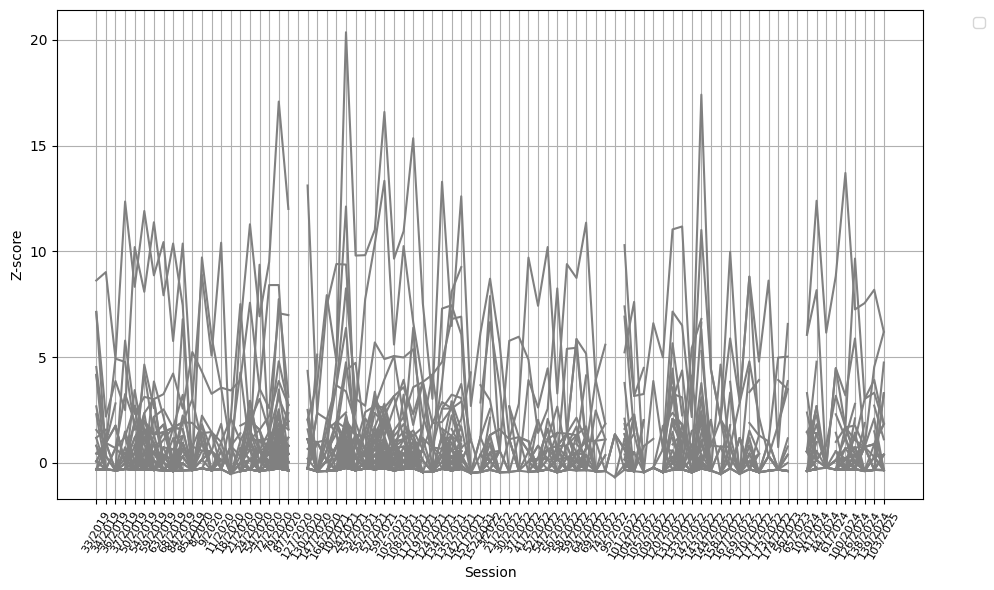

In [49]:
# speaker_1467_words_frequencies_sessions.csv
datatypes = {'speaker_id':str, 'session':str, 'word':str, 'word_n':int, 'word_freq':float, 'word_z':float}
csv = 'speaker_1467_words_frequencies_sessions.csv'
file_path = f'{directory}/csv_analysis/person_variance/session_frequency_z_score/{csv}'
df = pd.read_csv(file_path, sep=';', header=0, dtype=datatypes)
# check if sessions from years before 2023 and after 2022 exist
if (len([i for i in df['session'].unique() if int(i[-4:]) < CHATGPT_RELEASE_YEAR])>0 and len([i for i in df['session'].unique() if int(i[-4:]) > CHATGPT_RELEASE_YEAR])>0):

    words_list = [word for word in df['word'].unique() if (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])<CHATGPT_RELEASE_YEAR])].tolist()) & (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])>CHATGPT_RELEASE_YEAR])].tolist())]
    words_list = set(words_list)

    words_df = df[df['word'].isin(words_list)]

    # x-axis
    sessions_list = words_df['session'].unique()

    # Pivot to wide format: words as rows, sessions as columns
    pivot_df = words_df.pivot(index="word", columns="session", values="word_z")

    # Plot each word's z-scores across sessions (NaN handles missing values)
    plt.figure(figsize=(10, 6))
    for word in pivot_df.index:
        #plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-", color="grey")
        plt.plot(sessions_list, pivot_df.loc[word], label=None, linestyle="-", color="grey")
    plt.xlabel("Session")
    plt.ylabel("Z-score")
    plt.xticks(rotation=60, fontsize=8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
   


C:\Users\OMISTAJA\AppData\Local\Temp\ipykernel_8652\3164922113.py:31: RuntimeWarning: Mean of empty slice
  after_mean = np.nanmean(z_scores[cutoff_idx:])


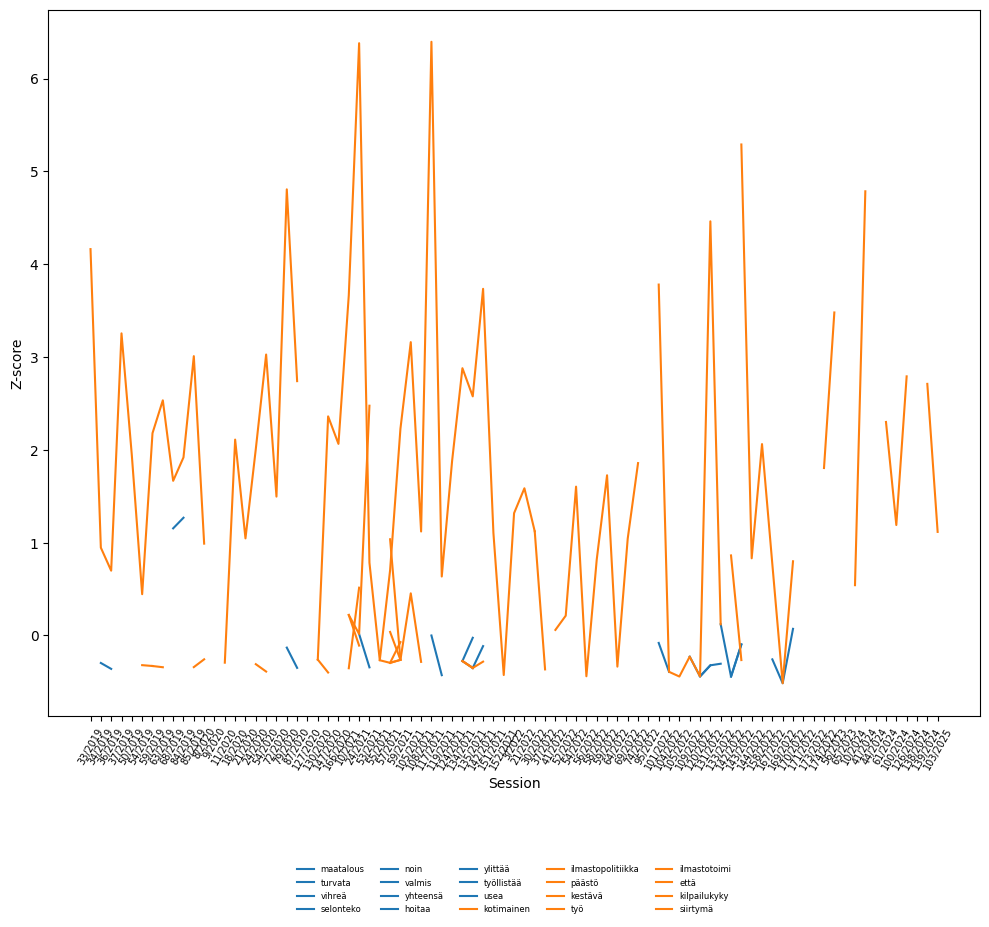

In [ ]:
# speaker_1467_words_frequencies_sessions.csv
datatypes = {'speaker_id':str, 'session':str, 'word':str, 'word_n':int, 'word_freq':float, 'word_z':float}
csv = 'speaker_1467_words_frequencies_sessions.csv'
file_path = f'{directory}/csv_analysis/person_variance/session_frequency_z_score/{csv}'
df = pd.read_csv(file_path, sep=';', header=0, dtype=datatypes)
# check if sessions from years before 2023 and after 2022 exist
if (len([i for i in df['session'].unique() if int(i[-4:]) < CHATGPT_RELEASE_YEAR])>0 and len([i for i in df['session'].unique() if int(i[-4:]) > CHATGPT_RELEASE_YEAR])>0):

    words_list = [word for word in df['word'].unique() if (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])<CHATGPT_RELEASE_YEAR])].tolist()) & (word in df['word'][df['session'].isin([session for session in df['session'].unique() if int(session[-4:])>CHATGPT_RELEASE_YEAR])].tolist())]
    words_list = set(words_list)

    words_df = df[df['word'].isin(words_list)]

    # x-axis
    sessions_list = words_df['session'].unique().tolist()

    # Pivot to wide format: words as rows, sessions as columns
    pivot_df = words_df.pivot(index="word", columns="session", values="word_z")

    # Index of cutoff in sessions_list: this shall be the first session after the year 2022
    cutoff = [i for i in sessions_list if int(i[-4:]) > CHATGPT_RELEASE_YEAR][0]
    cutoff_idx = sessions_list.index(cutoff)

    # since the list has been modified above: x-axis
    sessions_list = words_df['session'].unique().tolist()

    increasing_words = []
    for word in pivot_df.index:
        z_scores = pivot_df.loc[word].values
        before_mean = np.nanmean(z_scores[:cutoff_idx])
        after_mean = np.nanmean(z_scores[cutoff_idx:])
        if after_mean > before_mean:
            increasing_words.append(word)

    # Calculate mean z-scores before/after cutoff
    # All columns before and after cutoff
    before_means = pivot_df.iloc[:, :cutoff_idx].mean(axis=1)
    after_means = pivot_df.iloc[:, cutoff_idx:].mean(axis=1)
    diffs = after_means - before_means

    # Get top 20 words with largest positive difference
    words_20_largest_diffs = diffs.nlargest(20).index.tolist()

    # Plot each word's z-scores across sessions (NaN handles missing values)
    plt.figure(figsize=(10, 10))
    colours = plt.cm.tab10(np.linspace(0, 1, len(increasing_words)))
    for word in words_20_largest_diffs:
    #for word, colour in zip(increasing_words, colours):
        #plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-", color=colour)
        plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-")
    plt.xlabel("Session")
    plt.ylabel("Z-score")
    plt.xticks(rotation=60, fontsize=7)

    # Legend as a table below the plot
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),  # (x, y) position below the plot
        ncol=5,                      
        fontsize=7,                  
        frameon=False                # Optional: remove legend box
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust top margin to fit legend
    plt.show()
   

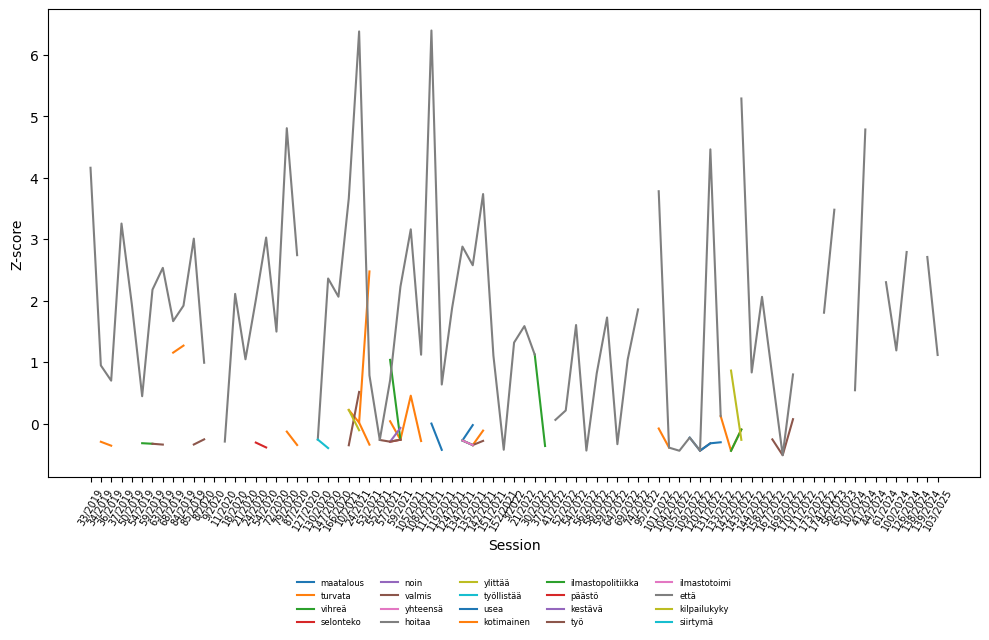

In [111]:
# Plot each word's z-scores across sessions (NaN handles missing values)
plt.figure(figsize=(10, 7))
colours = plt.cm.tab10(np.linspace(0, 1, len(increasing_words)))
for word in words_20_largest_diffs:
    plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-")
#for word, colour in zip(words_50_largest_diffs, colours):
#    plt.plot(sessions_list, pivot_df.loc[word], label=word, linestyle="-", color=colour)
plt.xlabel("Session")
plt.ylabel("Z-score")
plt.xticks(rotation=60, fontsize=7)

# Legend as a table below the plot
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),  # (x, y) position below the plot
    ncol=5,                      # Number of columns in the legend
    fontsize=6,                  # Smaller font
    frameon=False                # Optional: remove legend box
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust top margin to fit legend
plt.show()

In [ ]:
# Check if sessions _before_ and _after_ CHATGPT_RELSEASE_YEAR (2022) exist.
# If not, pass the speaker and move on to the next.
# First, create a dataframe to store the results.
speakers_words_anova = pd.DataFrame(columns=['speaker_id','word','statistic','pvalue','n_before','n_after']).astype({'speaker_id':str,'word':str,'statistic':float,'pvalue':float,'n_before':int,'n_after':int})
# Read csvs: each csv (speaker at a time)
for csv in [f for f in os.listdir(f'{directory}/csv_analysis/person_variance/') if re.search(r'speaker_.+\.csv$', f)]:
    df = pd.read_csv(f'{directory}/csv_analysis/person_variance/{csv}', sep=';', header=0, encoding='utf-8')
    # Check if the file contains sessions from both _before_ and _after CHATGPT_RELEASE_YEAR (2022)
    if (len([i for i in df['session'].unique() if int(i[-4:])<CHATGPT_RELEASE_YEAR])>0) & (len([i for i in df['session'].unique() if int(i[-4:])>CHATGPT_RELEASE_YEAR])>0):
        # Sessions exists.
        # Next: get all the unique words, store in a list: words
        words = df['word'].unique()
        speaker = df['speaker_id'].unique()[0].astype(str)
        # Loop through the words, get the word counts for sessions before and after CHATGPT_RELEASE_YEAR and store in respective lists
        for word in words:
            counts_before = df['word_n'].loc[(df['word']==word)&(df['session'].isin([i for i in df['session'].unique() if int(i[-4:])<CHATGPT_RELEASE_YEAR]))].tolist()
            counts_after = df['word_n'].loc[(df['word']==word)&(df['session'].isin([i for i in df['session'].unique() if int(i[-4:])>=CHATGPT_RELEASE_YEAR]))].tolist()
            # Run ANOVA if items exist in both lists: must have at least 5 observations in each group
            if (len(counts_before)>=5) & (len(counts_after)>=5):
                #print(f'word: {word}, counts_before: {len(counts_before)}, counts_after: {len(counts_after)}')
                try:
                    statistic, pvalue = stats.f_oneway(counts_before, counts_after, axis=0, equal_var=True, nan_policy='propagate', keepdims=False)
                    #print(f'statistic: {statistic}, pvalue: {pvalue}')
                    speakers_words_anova = pd.concat([speakers_words_anova, pd.DataFrame.from_dict(data={'speaker_id':[speaker],'word':[word],'statistic':[statistic],'pvalue':[pvalue],'n_before':[sum(counts_before)],'n_after':[sum(counts_after)]}, orient='columns')], axis=0, ignore_index=True)
                except Exception:
                    # if the sample is too small (too few observations) -> do nothing
                    pass

# Save ANOVA results as a csv
csv_save_path = f'{directory}/csv_analysis/person_variance/speakers_words_anova.csv'
try:
    speakers_words_anova.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(csv_save_path)
    speakers_words_anova.to_csv(csv_save_path, sep=';', header=True, index=False, encoding='utf-8')


In [ ]:
def get_normalised(df: pd.DataFrame, speaker_id: str, year: int, word_n: int) -> float:
    w_min = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].min()
    w_max = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].max()
    return ((word_n-w_min)/(w_max-w_min))